#Amazon Food Reviews Analysis Project
本项目用于分析亚马逊食物评论数据，包括评分分布、情感分析与关键词提取

In [3]:
import pandas as pd

df = pd.read_csv("../data/Reviews.csv")
print("找到数据：",df.head())
print("分析总评论数:",df.shape) 
print("字段类型:",df.isnull().sum())

找到数据：    Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d..

In [4]:
df = df.dropna(subset=["Text"])
df = df.drop_duplicates()

统计各评分数量: Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64


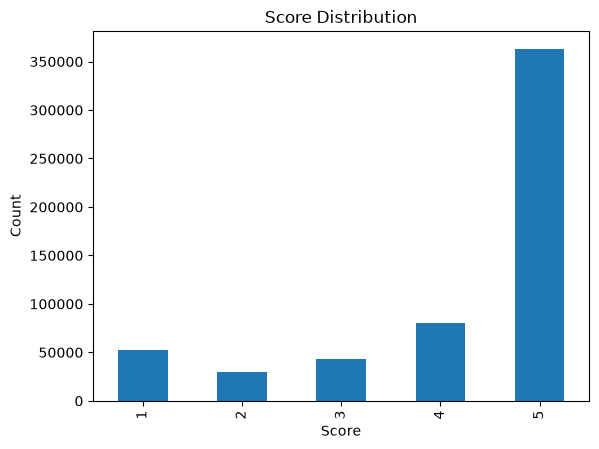

In [5]:
import matplotlib.pyplot as plt #画图
import matplotlib.pyplot as plt #可视化

rating_count = df["Score"].value_counts()
print("统计各评分数量:",rating_count)

rating_count.sort_index().plot(kind = "bar")
plt.title("Score Distribution")
plt.xlabel("Score") #情感
plt.ylabel("Count")

plt.show()

In [6]:
positive_rate = (
    len(df[df["Score"] >= 4]) / len(df)
)
print("用户满意度:",positive_rate)

用户满意度: 0.7806735461444549


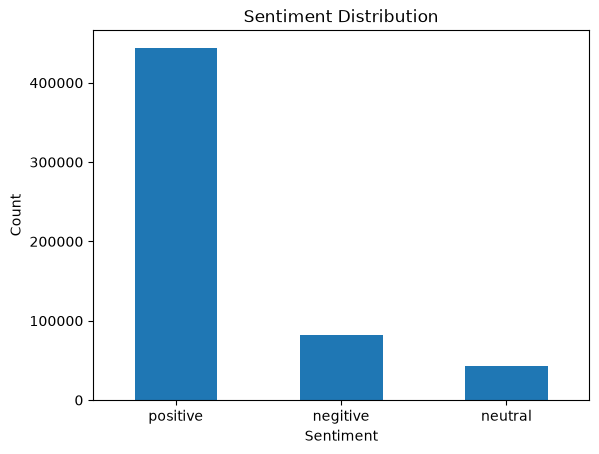

In [7]:
def sentiment_label(x):
    if x >= 4:
        return 'positive'
    elif x == 3:
        return 'neutral'
    else:
        return 'negitive'
df["sentiment"] = df["Score"].apply(sentiment_label)
df["sentiment"].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment") #情感
plt.ylabel("Count")
plt.xticks(rotation=360)

plt.show()

In [8]:
print("统计情感分布:",df["sentiment"].value_counts())
print("评分 vs 情感关系:",df.groupby('sentiment')['Score'].mean())

统计情感分布: sentiment
positive    443777
negitive     82037
neutral      42640
Name: count, dtype: int64
评分 vs 情感关系: sentiment
negitive    1.362873
neutral     3.000000
positive    4.818253
Name: Score, dtype: float64


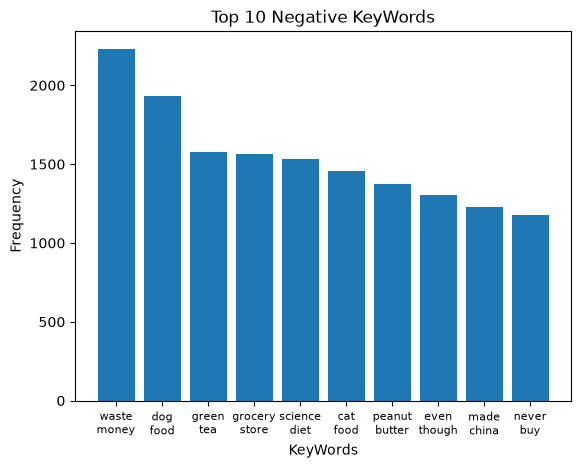

In [9]:
import re # 数据清洗 NLP
# 去停用词 也就是主谓宾词
import nltk 
nltk.download('stopwords',quiet=True)
from nltk.corpus import stopwords
# 定义两个组合在一起形成的差评词
from nltk.util import ngrams 
from collections import Counter # 查出差评高频关键词

stop_words = set(stopwords.words('english'))
bad_review = df[df['Score'] <= 2]['Text'].fillna('').astype(str)
bad_review_text = " ".join(
    bad_review.apply(
        lambda x: re.sub(r'[^\w\s]','',x.lower())
    )
)
bad_words = bad_review_text.split()

clean_words = [
    w for w in bad_words
    if w not in stop_words
    and len(w) > 2
    and w.isalpha()
]
#筛选掉 由 not good 两个字组成的差评词 加入这个评论数据里面差评常常出现的高频谓语词
bad_words_gl = {
    'would','could','should','know','think','thought','like','first','time','much','better','good','really',
    'also'
}
Zh_bigrams = list(ngrams(clean_words,2))
filter_bigrams = [
    bg for bg in Zh_bigrams
    if bg[0] not in bad_words_gl
    and bg[1] not in bad_words_gl
]
#让差评高频词更加人性化
badReview_top10_num = Counter(filter_bigrams).most_common(10)
#差评图
keywordsList = [' '.join(x[0]).replace(' ','\n') for x in badReview_top10_num]
badReview_top10Num_Scores = [x[1] for x in badReview_top10_num]

# plt.figure(figsize=(8,4))
plt.bar(keywordsList,badReview_top10Num_Scores)
plt.title('Top 10 Negative KeyWords')
plt.xlabel('KeyWords')
plt.ylabel('Frequency')

plt.xticks(fontsize=8)
plt.show() 

In [10]:
# 评分 vs 情感关系
print("评分 vs 情感关系:",pd.crosstab(df["Score"],df["sentiment"]))

评分 vs 情感关系: sentiment  negitive  neutral  positive
Score                                 
1             52268        0         0
2             29769        0         0
3                 0    42640         0
4                 0        0     80655
5                 0        0    363122


##结论
整体好感度还是可以，但是产品质量与口感需要升级一下，尤其是宠物粮食这一块